# Parameterized Analysis of Multiple MGnify Studies

![MGnify](../assets/figs/mgnify_banner.png)

This notebook runs a complete bacterial diversity analysis using a configuration dictionary to control all parameters.

**Key features:**
1. Single configuration dictionary for all analysis parameters
2. Linear execution flow without code repetition
3. Conditional plot generation based on flags
4. Automated output management

## Setup and Imports

In [1]:
import os
import pickle
from collections import defaultdict

# Dataframes and display
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# Plots
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

# Warning verbosity
import warnings 
warnings.filterwarnings(action="ignore")

import logging
logging.disable(logging.CRITICAL)

In [2]:
# Import all required functions
from momics.taxonomy import (
    clean_tax_row,
    fill_taxonomy_placeholders,
    remove_high_taxa,
    prevalence_cutoff,
    normalize_abundance,
    rarefy_table,
)

from mgnify_methods.taxonomy import (
    aggregate_by_taxonomic_level,
    fill_lower_taxa,
    pivot_taxonomic_data,
    invert_pivot_taxonomic_data,
    prevalence_cutoff_abund,
    remove_singletons_per_sample,
)

from mgnify_methods.utils.plot import (
    plot_rarefaction_mgnify,
    plot_season_reads_hist,
    save_plot_with_metadata,
    create_alpha_diversity_plots,
    plot_mean_std,
    plot_mean_ci,
    plot_feature_reads_hist,
)

from mgnify_methods.metacomp.rarefaction import rarefaction_curve
from mgnify_methods.stats import alpha_diversity_report, mean_std_curves, mean_ci_curves, extract_feature_dict
from mgnify_methods.utils.io import (
    import_taxonomy_summary,
    process_analysis_metadata,
    process_samples_metadata,
    enhance_samples_metadata,
    filter_number_reads,
)

from mgnify_methods import TaxonomyTable, AbundanceTable

# Beta diversity
from skbio.diversity import beta_diversity
from skbio.stats.ordination import pcoa

# Venn diagrams
from matplotlib_venn import venn2, venn3

## Configuration Dictionary

All analysis parameters are defined here. Modify this dictionary to control the entire analysis flow.

In [3]:
# ============================================================================
# ANALYSIS CONFIGURATION
# ============================================================================

CONFIG = {
    # === Data Sources ===
    'datasets': {
        'Sola': ['MGYS00006680', 'mgnify_data/SRP237882_taxonomy_abundances_SSU_v5.0.tsv'],
        'OSD2018': ['MGYS00006608', 'mgnify_data/ERP124424_taxonomy_abundances_SSU_v5.0.tsv'],
    },
    
    # === Output Configuration ===
    'output': {
        'use_timestamp': True,  # Create timestamped output folder
        'cache_dir': 'analysis_cache',  # Cache directory for downloaded data
    },
    
    # === Filtering Parameters ===
    'filtering': {
        'min_reads_cutoff': 25000,  # Minimum reads per sample
        'prevalence_percent': 0.005,  # Prevalence cutoff (0.5%)
        'remove_singletons': False,  # Remove taxa appearing only once per sample
    },
    
    # === Taxonomic Settings ===
    'taxonomy': {
        'ranks': ['superkingdom', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species'],
        'analysis_levels': ['phylum'],#, 'class', 'order', 'family', 'genus'],  # Levels for detailed analysis
        'diversity_level': 'family',  # Primary level for diversity calculations
        'filter_to_bacteria': True,  # Focus only on bacterial taxa
    },
    
    # === Sample Selection ===
    'samples': {
        'sample_type': 'prok',  # 'prok' or 'euk'
    },
    
    # === Rarefaction Settings ===
    'rarefaction': {
        'enabled': True,
        'depth': None,  # None = auto-calculate minimum depth
        'n_points': 50,  # Number of points for rarefaction curves
    },
    
    # === Diversity Analysis ===
    'diversity': {
        'alpha': {
            'enabled': True,
            'dropna': False,  # Drop NA values during aggregation
        },
        'beta': {
            'enabled': True,
            'metric': 'braycurtis',  # Distance metric
            'prevalence_cutoff': 0.01,  # Prevalence for beta diversity (1%)
        },
    },
    
    # === Feature Analysis ===
    'features': {
        'primary_feature': 'season',  # Main categorical feature for grouping
        'additional_features': ['study_tag'],  # Other features to analyze
    },
    
    # === Plot Flags ===
    'plots': {
        'reads_histogram': True,
        'taxonomic_overlap_venn': True,
        'rarefaction_curves': True,
        'rarefaction_mean_std': True,
        'rarefaction_mean_ci': True,
        'rarefaction_individual': False,  # Can be very cluttered
        'alpha_diversity': True,
        'beta_diversity_pcoa': True,
        'taxa_prevalence_violin': True,
        'feature_rarefaction': True,  # Rarefaction curves per feature value
        'save_figures': False,  # Save figures to output folder
        'dpi': 300,  # DPI for saved figures
    },
}

print("Configuration loaded successfully!")
print(f"\nDatasets: {list(CONFIG['datasets'].keys())}")
print(f"Taxonomic levels for analysis: {CONFIG['taxonomy']['analysis_levels']}")
print(f"Primary feature: {CONFIG['features']['primary_feature']}")

Configuration loaded successfully!

Datasets: ['Sola', 'OSD2018']
Taxonomic levels for analysis: ['phylum']
Primary feature: season


## Initialize Output Directories

In [4]:
# Extract configuration
TAXONOMY_RANKS = CONFIG['taxonomy']['ranks']
ds = CONFIG['datasets']

# Create output directories
if CONFIG['output']['use_timestamp']:
    stamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M')
    OUT_FOLDER = os.path.abspath('analysis_' + stamp)
else:
    OUT_FOLDER = os.path.abspath('analysis_latest')

ANALYSIS_CACHE = os.path.abspath(CONFIG['output']['cache_dir'])

for folder in [OUT_FOLDER, ANALYSIS_CACHE]:
    if not os.path.exists(folder):
        os.makedirs(folder)
        print(f"Created directory: {folder}")
    else:
        print(f"Directory exists: {folder}")

# Save configuration to output folder
import json
config_path = os.path.join(OUT_FOLDER, 'analysis_config.json')
with open(config_path, 'w') as f:
    json.dump(CONFIG, f, indent=2)
print(f"\nConfiguration saved to: {config_path}")

Created directory: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260206_1816
Directory exists: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_cache

Configuration saved to: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260206_1816/analysis_config.json


## Load Metadata from MGnify

In [5]:
# Fetch analysis metadata
analysis_meta = process_analysis_metadata(ANALYSIS_CACHE, ds)
print(f"Loaded {len(analysis_meta)} analyses")

# Fetch and enhance sample metadata
samples_meta = process_samples_metadata(ANALYSIS_CACHE, ds)
samples_meta = enhance_samples_metadata(samples_meta)
print(f"Loaded {len(samples_meta)} samples")

Loaded 345 analyses
Loaded 202 samples


## Filter Samples by Read Count


=== Reads Distribution (Unfiltered) ===
Samples not matched to season metadata: 143


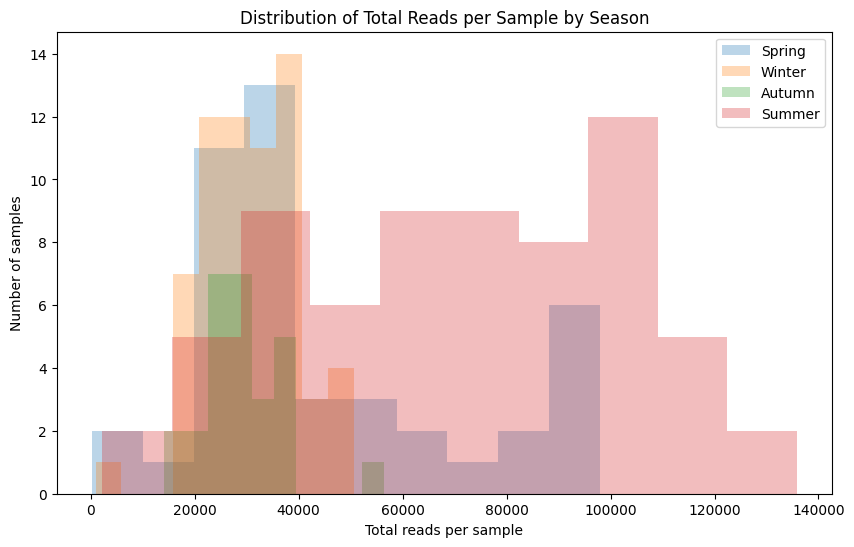

Samples not matched to study_tag metadata: 143


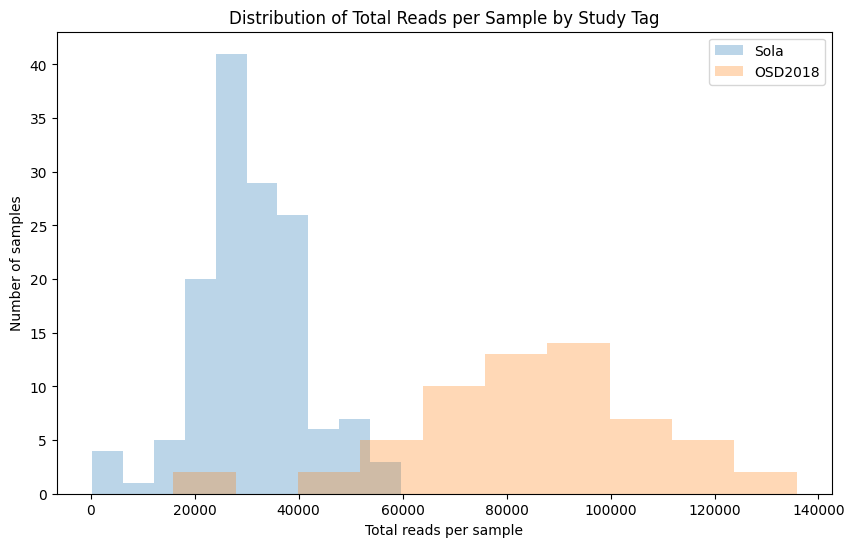


Filtering samples with < 25000 reads: 37 samples to remove
Remaining analyses after filtering: 308

=== Reads Distribution (Filtered) ===
Samples not matched to season metadata: 143


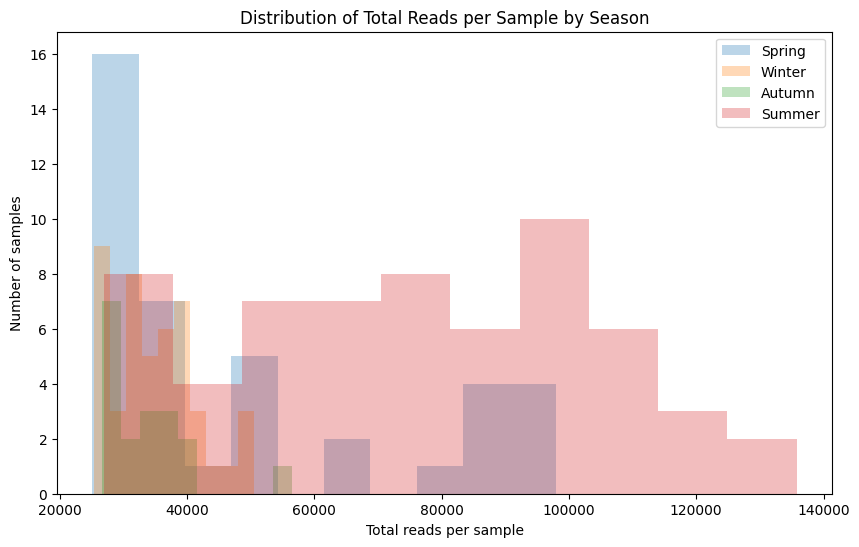

In [6]:
# Plot reads distribution before filtering
if CONFIG['plots']['reads_histogram']:
    print("\n=== Reads Distribution (Unfiltered) ===")
    total_dict = plot_season_reads_hist(
        analysis_meta,
        samples_meta,
        name='season_reads_unfiltered.png' if CONFIG['plots']['save_figures'] else None,
        out_dir=OUT_FOLDER if CONFIG['plots']['save_figures'] else None,
        use_robust_save=False,
    )
    
    # Plot for additional features
    for feature in CONFIG['features']['additional_features']:
        if feature in samples_meta.columns:
            plot_feature_reads_hist(
                analysis_meta=analysis_meta,
                samples_meta=samples_meta,
                feature=feature,
                name=f'{feature}_reads_unfiltered.png' if CONFIG['plots']['save_figures'] else None,
                out_dir=OUT_FOLDER if CONFIG['plots']['save_figures'] else None,
                use_robust_save=False,
            )

# Apply filtering
cutoff = CONFIG['filtering']['min_reads_cutoff']
to_drop = filter_number_reads(total_dict, cutoff)
print(f"\nFiltering samples with < {cutoff} reads: {len(to_drop)} samples to remove")

for sample in to_drop:
    analysis_meta = analysis_meta[analysis_meta.index != sample]

print(f"Remaining analyses after filtering: {len(analysis_meta)}")

# Plot reads distribution after filtering
if CONFIG['plots']['reads_histogram']:
    print("\n=== Reads Distribution (Filtered) ===")
    total_dict = plot_season_reads_hist(
        analysis_meta,
        samples_meta,
        name='season_reads_filtered.png' if CONFIG['plots']['save_figures'] else None,
        out_dir=OUT_FOLDER if CONFIG['plots']['save_figures'] else None,
        use_robust_save=False,
    )

## Load and Merge Taxonomy Data

In [7]:
# Get data folder path
root_folder = os.path.abspath(os.path.join('../'))
data_folder = os.path.join(root_folder, 'data')

# Load taxonomy summaries
dfs = {}
for k, values in ds.items():
    path = values[1]
    dfs[k] = import_taxonomy_summary(data_folder, path)
    print(f"Loaded {k}: {dfs[k].shape}")

# Merge all taxonomy dataframes
from functools import reduce
df_tax_summary = reduce(
    lambda left, right: pd.merge(left, right, on='#SampleID', how='outer'),
    dfs.values()
)
df_tax_summary = df_tax_summary.astype("Int32").fillna(0)
print(f"\nMerged taxonomy table: {df_tax_summary.shape}")

Loaded Sola: (3484, 283)
Loaded OSD2018: (1981, 62)



Merged taxonomy table: (4221, 345)


## Synchronize Metadata and Taxonomy Tables

In [8]:
# Remove samples not in metadata
to_drop = []
for sample in analysis_meta.index:
    data_id = analysis_meta.loc[sample, 'relationships.sample.data.id']
    if data_id not in samples_meta['id'].values:
        to_drop.append(sample)

if to_drop:
    bef = analysis_meta.shape[0]
    analysis_meta = analysis_meta[~analysis_meta.index.isin(to_drop)]
    after = analysis_meta.shape[0]
    print(f"Dropped {len(to_drop)} samples from analysis_meta: {bef} -> {after}")

# Filter taxonomy table to match analysis_meta
print(f'\nTaxonomy samples before filtering: {df_tax_summary.shape[1]}')
for col in df_tax_summary.columns:
    if col not in analysis_meta.index:
        df_tax_summary.drop(columns=[col], inplace=True)
print(f'Taxonomy samples after filtering: {df_tax_summary.shape[1]}')

# Remove taxa with all zero counts
zero_rows = df_tax_summary[(df_tax_summary == 0).all(axis=1)]
print(f"\nRemoving {zero_rows.shape[0]} taxa with all zero counts")
df_tax_summary = df_tax_summary.loc[~(df_tax_summary == 0).all(axis=1)]

# Verify data integrity
assert len(df_tax_summary[df_tax_summary.index=='sk__Archaea']) == 1, "Missing Archaea row"
assert len(df_tax_summary[df_tax_summary.index=='sk__Eukaryota']) == 1, "Missing Eukaryota row"
assert analysis_meta['relationships.sample.data.id'].size == len(df_tax_summary.columns), "Sample count mismatch"

lst1 = sorted(analysis_meta.index.tolist())
lst2 = sorted(df_tax_summary.columns.tolist())
assert lst1 == lst2, "Sample IDs don't match between metadata and taxonomy"

print("\n✓ Data tables synchronized successfully")

Dropped 143 samples from analysis_meta: 308 -> 165

Taxonomy samples before filtering: 345
Taxonomy samples after filtering: 165

Removing 1965 taxa with all zero counts

✓ Data tables synchronized successfully


## Convert to TaxonomyTable Format

In [9]:
# Convert abundance table to taxonomy table
abundance_table = AbundanceTable(df_tax_summary.reset_index(), source='tax_mgnify_raw')
ncbi_flag, taxonomy_table = abundance_table.to_taxonomy_table()

# Verify conversion
long_df = invert_pivot_taxonomic_data(df_tax_summary, target_col=['#SampleID'])
long_df.sort_values(by=['source material ID', 'abundance'], inplace=True)
taxonomy_table.df.sort_values(by=['source material ID', 'abundance'], inplace=True)

assert long_df['abundance'].sum() == taxonomy_table.df['abundance'].sum(), "Abundance sum mismatch"
print("✓ Conversion verified")

# Fill missing taxonomic information
taxonomy_table.df = fill_lower_taxa(taxonomy_table.df, TAXONOMY_RANKS)
taxonomy_table.df = fill_taxonomy_placeholders(taxonomy_table.df, TAXONOMY_RANKS)

if not taxonomy_table.df.index.name == 'source material ID':
    taxonomy_table.df = taxonomy_table.df.set_index('source material ID')

print(f"\nTaxonomy table ready: {taxonomy_table.df.shape}")
del long_df

✓ Conversion verified

Taxonomy table ready: (46870, 9)


## Filter to Target Sample Type

In [10]:
# Get sample list for selected sample type
sample_type = CONFIG['samples']['sample_type']
sample_list = samples_meta[samples_meta['sample_type'] == sample_type]['id'].tolist()
data_list = analysis_meta[analysis_meta['relationships.sample.data.id'].isin(sample_list)].index.tolist()

# Filter taxonomy table
taxonomy_table.df_filt = taxonomy_table.df[taxonomy_table.df.index.isin(data_list)]

print(f"Filtered to {sample_type} samples: {len(data_list)} samples")
print(f"Filtered taxonomy table: {taxonomy_table.df_filt.shape}")

Filtered to prok samples: 165 samples
Filtered taxonomy table: (46870, 9)


## Taxonomic Overlap Analysis


=== Taxonomic Overlap Analysis ===


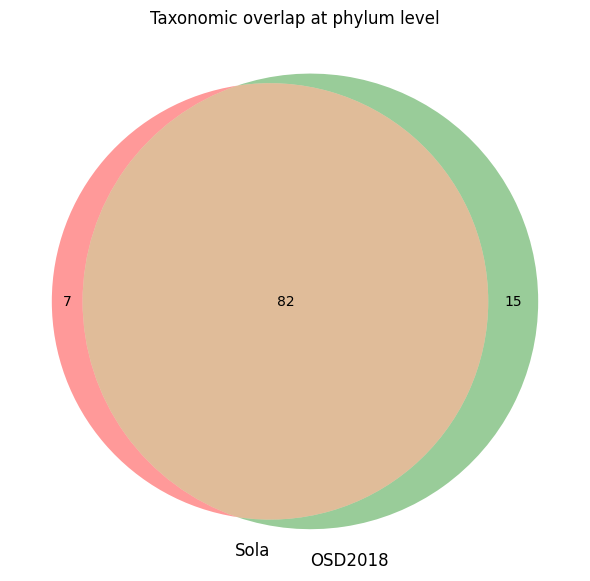

In [12]:
if CONFIG['plots']['taxonomic_overlap_venn']:
    print("\n=== Taxonomic Overlap Analysis ===")
    
    tax_levels = CONFIG['taxonomy']['analysis_levels']
    fig, axes = plt.subplots(1, len(tax_levels), figsize=(6 * len(tax_levels), 8))
    axes = np.atleast_1d(axes)
    
    for ax, tax in zip(axes, tax_levels):
        long_df_filt = aggregate_by_taxonomic_level(
            taxonomy_table.df_filt, level=tax, dropna=False
        )
        df_filt_pivot = pivot_taxonomic_data(long_df_filt)
        df_filt_pivot = df_filt_pivot[(df_filt_pivot > 0).any(axis=1)]
        
        if CONFIG['taxonomy']['filter_to_bacteria']:
            df_filt_pivot = df_filt_pivot[df_filt_pivot.index.str.startswith('sk__Bacteria')]
        
        sets = []
        labels = list(ds.keys())
        for study in labels:
            sample_ids = analysis_meta[analysis_meta['study_tag'] == study].index.tolist()
            sample_ids = [s for s in sample_ids if s in df_filt_pivot.columns]
            taxa_in_study = set(df_filt_pivot[sample_ids][df_filt_pivot[sample_ids].sum(axis=1) > 0].index.tolist())
            sets.append(taxa_in_study)
        
        if len(sets) == 2:
            venn2(subsets=(sets[0], sets[1]), set_labels=labels, ax=ax)
        elif len(sets) == 3:
            venn3(subsets=(sets[0], sets[1], sets[2]), set_labels=labels, ax=ax)
        else:
            ax.text(0.5, 0.5, f"Venn not supported for {len(sets)} sets", 
                   ha='center', va='center')
            ax.set_xticks([])
            ax.set_yticks([])
        
        ax.set_title(f'Taxonomic overlap at {tax} level')
    
    plt.tight_layout()
    if CONFIG['plots']['save_figures']:
        plt.savefig(os.path.join(OUT_FOLDER, 'taxonomic_overlap.png'), 
                   dpi=CONFIG['plots']['dpi'])
    plt.show()

## Alpha Diversity Analysis


=== Alpha Diversity Analysis ===
Analyzing at family level...
Data: 165 samples, 905 taxa
Study distribution: {'Sola': 107, 'OSD2018': 58}
Calculated diversity for 165 samples

Saved diversity results to: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260206_1816/alpha_diversity_family.csv


shannon                                                  simpson  \
            count   mean    std    min    25%    50%    75%    max   count   
study_tag                                                                    
OSD2018      58.0  2.873  0.454  1.036  2.650  2.861  3.133  4.226    58.0   
Sola        107.0  2.757  0.197  1.941  2.673  2.762  2.887  3.161   107.0   

                                                           observed_otus  \
            mean    std    min    25%    50%    75%    max         count   
study_tag                                                                  
OSD2018    0.875  0.076  0.418  0.862  0.888  0.915  0.971          58.0   
Sola       0.877  0.035  0.682  0.868  0.885  0.896  0.917         107.0   

                                                                 chao1  \
              mean     std    min     25%    50%     75%    max  count   
study_tag                                                                
OSD2018    227.431  61.151   71.0  195.75  218.0  262.25  436.0   58.0   
Sola       181.626  46.426  124.0  152.00  170.0  198.50  378.0  107.0   

                                                                         
              mean     std      min      25%      50%      75%      max  
study_tag                                                                
OSD2018    287.986  74.476   86.833  237.574  290.465  321.638  503.038  
Sola       250.328  63.551  141.250  203.708  241.231  280.495  444.455

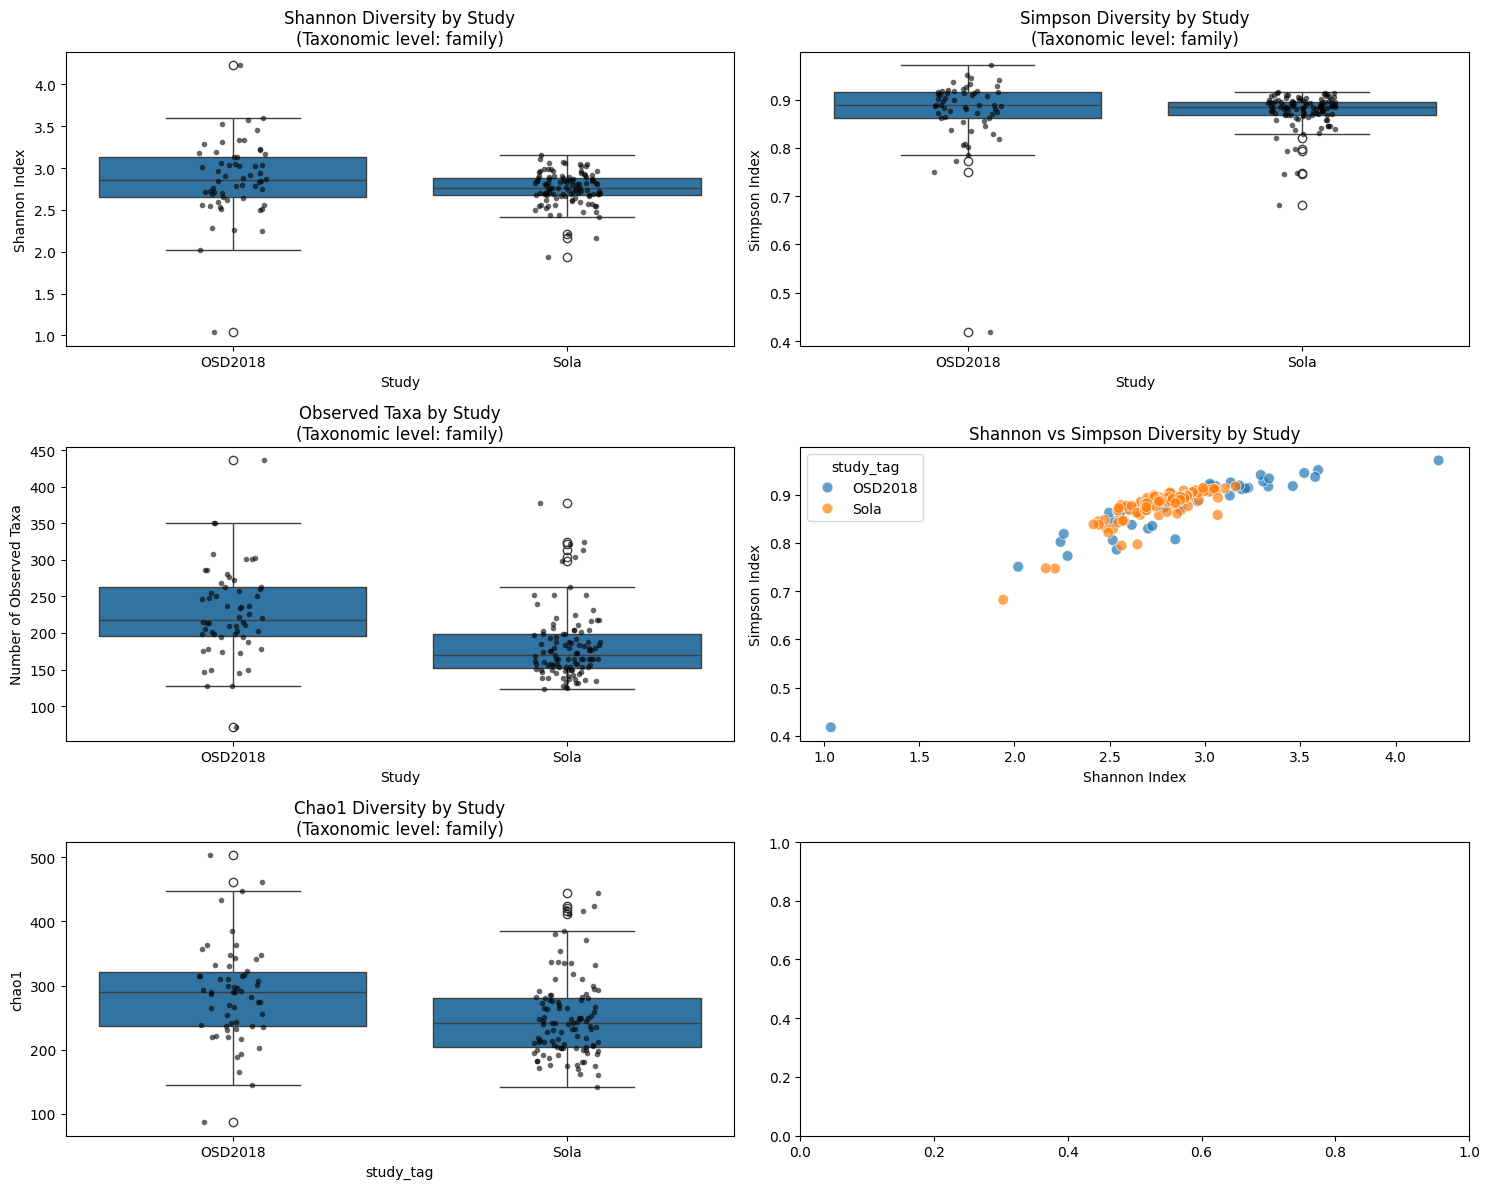


STATISTICAL COMPARISON OF ALPHA DIVERSITY BETWEEN STUDIES

SHANNON - Mann-Whitney U test:
  OSD2018 (n=58): median = 2.861
  Sola (n=107): median = 2.762
  U-statistic = 3789.000, p-value = 0.0193
  Significant difference: Yes

SIMPSON - Mann-Whitney U test:
  OSD2018 (n=58): median = 0.888
  Sola (n=107): median = 0.885
  U-statistic = 3538.000, p-value = 0.1381
  Significant difference: No

OBSERVED_OTUS - Mann-Whitney U test:
  OSD2018 (n=58): median = 218.000
  Sola (n=107): median = 170.000
  U-statistic = 4700.500, p-value = 0.0000
  Significant difference: Yes

CHAO1 - Mann-Whitney U test:
  OSD2018 (n=58): median = 290.465
  Sola (n=107): median = 241.231
  U-statistic = 4229.000, p-value = 0.0001
  Significant difference: Yes


In [13]:
if CONFIG['diversity']['alpha']['enabled']:
    print("\n=== Alpha Diversity Analysis ===")
    
    dropna = CONFIG['diversity']['alpha']['dropna']
    tax_level_for_diversity = CONFIG['taxonomy']['diversity_level']
    
    print(f"Analyzing at {tax_level_for_diversity} level...")
    
    # Aggregate data
    long_df_filt = aggregate_by_taxonomic_level(
        taxonomy_table.df_filt, level=tax_level_for_diversity, dropna=dropna
    )
    df_diversity_pivot = pivot_taxonomic_data(long_df_filt)
    
    # Optional: Remove singletons
    if CONFIG['filtering']['remove_singletons']:
        df_diversity_pivot = remove_singletons_per_sample(df_diversity_pivot, skip_columns=0)
        print("Removed singletons per sample")
    
    # Transpose for diversity calculation
    df_diversity_transposed = df_diversity_pivot.T
    df_diversity_transposed.index.name = 'sample_id'
    
    # Create factors DataFrame
    factors_df = pd.DataFrame(index=df_diversity_transposed.index)
    factors_df['study_tag'] = factors_df.index.map(
        lambda x: analysis_meta[analysis_meta.index == x]['study_tag'].iloc[0]
    )
    
    # Add season information
    for sample in factors_df.index:
        sample_meta_row = samples_meta[
            samples_meta['id'] == analysis_meta[analysis_meta.index == sample].index[0]
        ]
        factors_df.loc[sample, 'season'] = (
            sample_meta_row['season'].iloc[0] 
            if not sample_meta_row.empty and 'season' in sample_meta_row.columns 
            else 'Unknown'
        )
    
    print(f"Data: {df_diversity_transposed.shape[0]} samples, {df_diversity_transposed.shape[1]} taxa")
    print(f"Study distribution: {factors_df['study_tag'].value_counts().to_dict()}")
    
    # Calculate diversity
    diversity_df, diversity_results, diversity_metrics = alpha_diversity_report(
        df_diversity_transposed,
        factors_df,
    )
    
    # Save results
    diversity_path = os.path.join(OUT_FOLDER, f'alpha_diversity_{tax_level_for_diversity}.csv')
    diversity_df.to_csv(diversity_path, index=False)
    print(f"\nSaved diversity results to: {diversity_path}")
    
    # Display summary
    display(diversity_df.groupby('study_tag')[diversity_metrics].describe().round(3))
    
    # Plot diversity
    if CONFIG['plots']['alpha_diversity']:
        fig_alpha = create_alpha_diversity_plots(diversity_df, diversity_metrics, tax_level_for_diversity)
        if CONFIG['plots']['save_figures']:
            fig_alpha.savefig(
                os.path.join(OUT_FOLDER, f'alpha_diversity_{tax_level_for_diversity}.png'),
                dpi=CONFIG['plots']['dpi'], bbox_inches='tight'
            )
        plt.show()

## Calculate Minimum Rarefaction Depth

In [14]:
if CONFIG['rarefaction']['enabled']:
    print("\n=== Calculating Minimum Rarefaction Depth ===")
    
    tax_levels = CONFIG['taxonomy']['analysis_levels']
    dropna = CONFIG['diversity']['alpha']['dropna']
    
    MIN_DEPTH = 1e9
    for tax in tax_levels:
        long_df_filt = aggregate_by_taxonomic_level(
            taxonomy_table.df_filt, level=tax, dropna=dropna
        )
        df_filt_pivot = pivot_taxonomic_data(long_df_filt)
        df_filt_pivot = prevalence_cutoff_abund(
            df_filt_pivot, 
            percent=CONFIG['filtering']['prevalence_percent'], 
            skip_columns=0
        )
        df_filt_pivot = rarefy_table(df_filt_pivot, depth=None)
        MIN_DEPTH = min(MIN_DEPTH, df_filt_pivot.sum().min())
    
    print(f"Minimum rarefaction depth: {int(MIN_DEPTH)}")
    
    # Override if depth is specified in config
    if CONFIG['rarefaction']['depth'] is not None:
        MIN_DEPTH = CONFIG['rarefaction']['depth']
        print(f"Using configured depth: {int(MIN_DEPTH)}")


=== Calculating Minimum Rarefaction Depth ===
Prevalence cutoff at 0.005% (max threshold 3.55005): reduced from (140, 165) to (109, 165)
Minimum rarefaction depth: 14591
Minimum rarefaction depth: 14591


## Rarefaction Curve Calculation

In [15]:
def calc_rarefaction_curves(df_pivot, analysis_meta, curves):
    """
    Calculate rarefaction curves for all samples in the pivot table.
    Groups curves by study_tag.
    """
    for sample in df_pivot.columns:
        # Get study tag
        study = analysis_meta.loc[sample, 'study_tag']
        
        # Get reads for this sample
        reads = np.repeat(df_pivot.index, df_pivot[sample].values)
        
        # Calculate rarefaction curve
        depths, richness = rarefaction_curve(reads)
        curves[study].append((depths, richness))
    
    return curves

In [16]:
if CONFIG['rarefaction']['enabled'] and CONFIG['plots']['rarefaction_curves']:
    print("\n=== Rarefaction Curves per Taxonomic Level ===")
    
    pkl_path = os.path.join(ANALYSIS_CACHE, "rarefaction_curves_per_taxon.pkl")
    rarefied_tables = {sample_type: {}}
    
    # Check if already computed
    if os.path.exists(pkl_path):
        print("Loading cached rarefaction curves...")
        with open(pkl_path, 'rb') as f:
            curves_per_feature = pickle.load(f)
        calc_rarefaction = False
    else:
        print("Computing rarefaction curves...")
        calc_rarefaction = True
        curves_per_feature = {}
    
    # Process each taxonomic level
    for tax in tax_levels:
        print(f"  Processing {tax}...")
        long_df_filt = aggregate_by_taxonomic_level(
            taxonomy_table.df_filt, level=tax, dropna=dropna
        )
        df_filt_pivot = pivot_taxonomic_data(long_df_filt)
        df_filt_pivot = prevalence_cutoff_abund(
            df_filt_pivot, 
            percent=CONFIG['filtering']['prevalence_percent'], 
            skip_columns=0
        )
        
        if calc_rarefaction:
            curves = defaultdict(list)
            curves = calc_rarefaction_curves(df_filt_pivot, analysis_meta, curves)
            curves_per_feature[tax] = curves
        
        df_filt_pivot = rarefy_table(df_filt_pivot, depth=MIN_DEPTH)
        rarefied_tables[sample_type][tax] = df_filt_pivot
    
    if calc_rarefaction:
        with open(pkl_path, 'wb') as f:
            pickle.dump(curves_per_feature, f)
        print("Rarefaction curves cached.")


=== Rarefaction Curves per Taxonomic Level ===
Computing rarefaction curves...
  Processing phylum...
Prevalence cutoff at 0.005% (max threshold 3.55005): reduced from (140, 165) to (109, 165)
Minimum rarefaction depth: 14591
Rarefaction curves cached.


## Plot Rarefaction Curves


=== Mean ± STD Rarefaction Curves ===


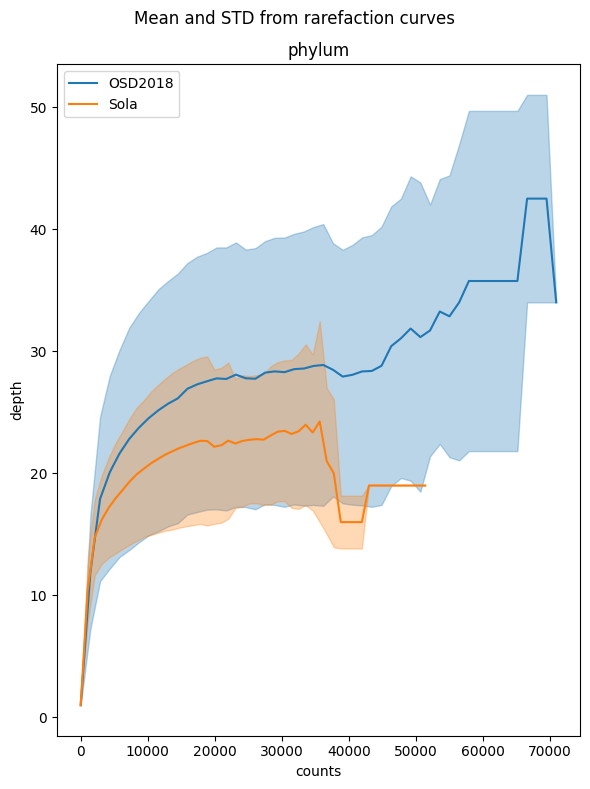


=== Mean ± CI Rarefaction Curves ===


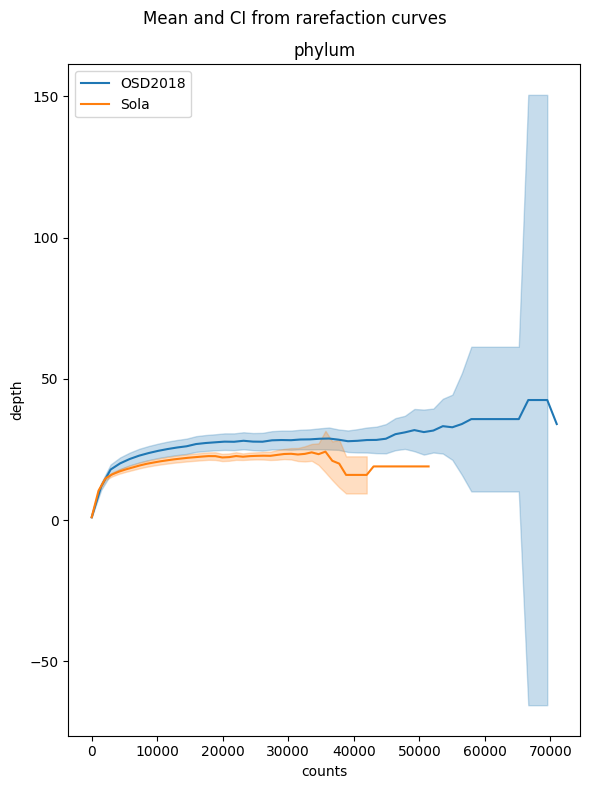

In [19]:
if CONFIG['rarefaction']['enabled']:
    # Mean + STD plots
    if CONFIG['plots']['rarefaction_mean_std']:
        print("\n=== Mean ± STD Rarefaction Curves ===")
        fig, axes = plt.subplots(1, len(tax_levels), figsize=(6 * len(tax_levels), 8))
        axes = np.atleast_1d(axes)
        
        for ax, tax in zip(axes, tax_levels):
            for campaign, curve_list in curves_per_feature[tax].items():
                x_common, mean_y, std_y, counts = mean_std_curves(
                    curve_list, n_points=CONFIG['rarefaction']['n_points']
                )
                plot_mean_std(x_common, mean_y, std_y, label=campaign, ax=ax, title=tax)
        
        plt.suptitle("Mean and STD from rarefaction curves")
        plt.tight_layout()
        if CONFIG['plots']['save_figures']:
            plt.savefig(os.path.join(OUT_FOLDER, 'rarefaction_mean_std.png'), 
                       dpi=CONFIG['plots']['dpi'])
        plt.show()
    
    # Mean + CI plots
    if CONFIG['plots']['rarefaction_mean_ci']:
        print("\n=== Mean ± CI Rarefaction Curves ===")
        fig, axes = plt.subplots(1, len(tax_levels), figsize=(6 * len(tax_levels), 8))
        axes = np.atleast_1d(axes)
        
        for ax, tax in zip(axes, tax_levels):
            for campaign, curve_list in curves_per_feature[tax].items():
                x_common, mean_y, ci_lo, ci_hi, counts = mean_ci_curves(
                    curve_list, n_points=CONFIG['rarefaction']['n_points']
                )
                plot_mean_ci(x_common, mean_y, ci_lo, ci_hi, label=campaign, ax=ax, title=tax)
        
        plt.suptitle("Mean and CI from rarefaction curves")
        plt.tight_layout()
        if CONFIG['plots']['save_figures']:
            plt.savefig(os.path.join(OUT_FOLDER, 'rarefaction_mean_ci.png'), 
                       dpi=CONFIG['plots']['dpi'])
        plt.show()
    
    # Individual curves
    if CONFIG['plots']['rarefaction_individual']:
        print("\n=== Individual Rarefaction Curves ===")
        fig, axes = plt.subplots(1, len(tax_levels), figsize=(6 * len(tax_levels), 8))
        
        for ax, tax in zip(axes, tax_levels):
            ci = 0
            for campaign, curve_list in curves_per_feature[tax].items():
                for c in curve_list:
                    ax.plot(c[0], c[1], label=campaign, color=f"C{ci}", alpha=0.45, lw=0.8)
                ci += 1
            
            handles, labels = ax.get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(), by_label.keys())
            ax.set_xlabel("Number of reads")
            ax.set_ylabel("Observed richness")
            ax.set_title(tax)
        
        plt.tight_layout()
        if CONFIG['plots']['save_figures']:
            plt.savefig(os.path.join(OUT_FOLDER, 'rarefaction_individual.png'), 
                       dpi=CONFIG['plots']['dpi'])
        plt.show()

## Beta Diversity Analysis


=== Beta Diversity Analysis ===
Analyzing at family level...
Minimum rarefaction depth: 14591
Rarefied to depth: 14591
Prevalence cutoff at 0.01% (max threshold 1.4591): reduced from (905, 165) to (585, 165)
Data: 165 samples, 585 taxa
Samples not matched to season metadata: 0
Explained variance: PC1=27.87%, PC2=12.11%


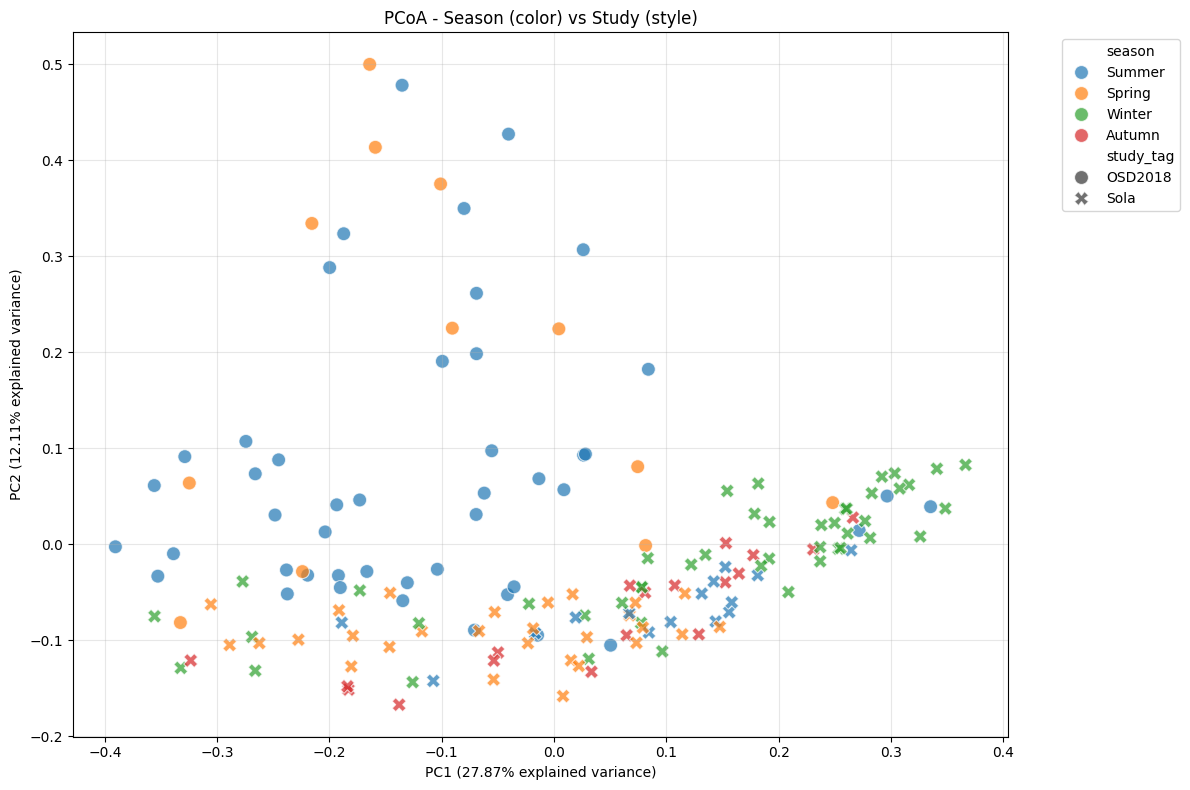

In [20]:
if CONFIG['diversity']['beta']['enabled']:
    print("\n=== Beta Diversity Analysis ===")
    
    tax_level_for_diversity = CONFIG['taxonomy']['diversity_level']
    print(f"Analyzing at {tax_level_for_diversity} level...")
    
    # Prepare data
    long_df_filt = aggregate_by_taxonomic_level(
        taxonomy_table.df_filt, level=tax_level_for_diversity, dropna=dropna
    )
    df_diversity_pivot = pivot_taxonomic_data(long_df_filt)
    
    # Apply rarefaction and prevalence filtering
    if CONFIG['rarefaction']['enabled']:
        df_diversity_pivot = rarefy_table(df_diversity_pivot, depth=MIN_DEPTH)
        print(f"Rarefied to depth: {int(MIN_DEPTH)}")
    
    df_diversity_pivot = prevalence_cutoff_abund(
        df_diversity_pivot, 
        percent=CONFIG['diversity']['beta']['prevalence_cutoff'], 
        skip_columns=0
    )
    df_diversity_input = df_diversity_pivot.T
    
    print(f"Data: {df_diversity_input.shape[0]} samples, {df_diversity_input.shape[1]} taxa")
    
    # Calculate beta diversity and PCoA
    assert sorted(analysis_meta.index) == sorted(df_diversity_input.index), "Index mismatch"
    
    beta = beta_diversity(metric=CONFIG['diversity']['beta']['metric'], counts=df_diversity_input)
    pcoa_result = pcoa(beta, method="eigh")
    explained_variance = (
        pcoa_result.proportion_explained[0],
        pcoa_result.proportion_explained[1],
    )
    
    # Merge with metadata
    pcoa_df = pd.merge(
        pcoa_result.samples,
        analysis_meta,
        left_index=True,
        right_index=True,
        how="inner",
    )
    
    # Add feature information
    feature = CONFIG['features']['primary_feature']
    features_dict = extract_feature_dict(analysis_meta, samples_meta, feature=feature)
    pcoa_df[feature] = 'Unknown'
    for feature_val, samples in features_dict.items():
        sample_subset = list(samples.keys())
        pcoa_df.loc[pcoa_df.index.isin(sample_subset), feature] = feature_val
    
    print(f"Explained variance: PC1={explained_variance[0]:.2%}, PC2={explained_variance[1]:.2%}")
    
    # Plot PCoA
    if CONFIG['plots']['beta_diversity_pcoa']:
        fig, ax = plt.subplots(figsize=(12, 8))
        
        sns.scatterplot(
            data=pcoa_df,
            x='PC1', y='PC2',
            hue=feature,
            style='study_tag',
            s=100,
            alpha=0.7,
            ax=ax
        )
        
        ax.set_xlabel(f'PC1 ({explained_variance[0]:.2%} explained variance)')
        ax.set_ylabel(f'PC2 ({explained_variance[1]:.2%} explained variance)')
        ax.set_title(f'PCoA - {feature.capitalize()} (color) vs Study (style)')
        ax.grid(True, alpha=0.3)
        
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        
        if CONFIG['plots']['save_figures']:
            plt.savefig(os.path.join(OUT_FOLDER, f'beta_pcoa_{feature}.png'), 
                       dpi=CONFIG['plots']['dpi'], bbox_inches='tight')
        plt.show()

## Taxa Prevalence Violin Plot


=== Taxa Prevalence per Taxonomic Level ===


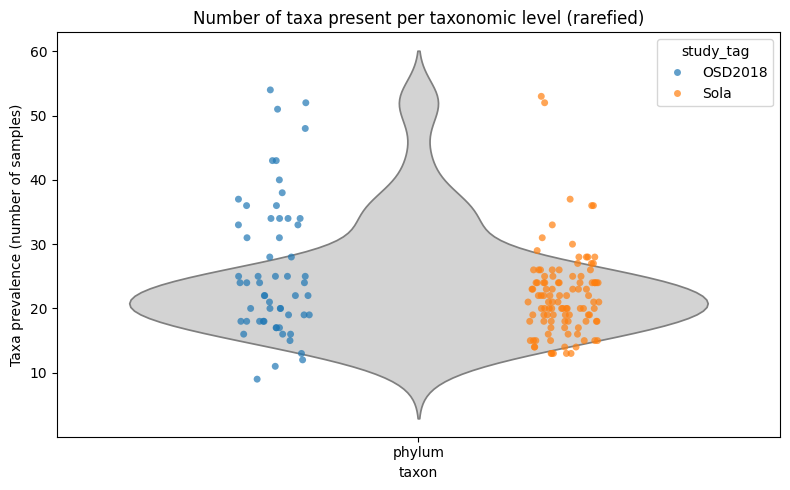

In [21]:
if CONFIG['plots']['taxa_prevalence_violin']:
    print("\n=== Taxa Prevalence per Taxonomic Level ===")
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    combined = []
    for tax, table in rarefied_tables[sample_type].items():
        df = table > 0
        combined.append(df.sum().reset_index().assign(tax=tax))
    
    df_all = pd.concat(combined, ignore_index=True)
    df_all.rename(columns={0: 'counts', 'tax': 'taxon'}, inplace=True)
    df_all = df_all.merge(
        analysis_meta[['study_tag']],
        left_on='index',
        right_index=True,
        how='left'
    )
    
    sns.violinplot(
        data=df_all,
        x="taxon", y="counts",
        inner=None, color="lightgray",
        ax=ax
    )
    
    sns.stripplot(
        data=df_all,
        x="taxon", y="counts",
        dodge=True,
        hue='study_tag',
        jitter=True, alpha=0.7,
        ax=ax
    )
    
    ax.set_title(f"Number of taxa present per taxonomic level (rarefied)")
    ax.set_ylabel("Taxa prevalence (number of samples)")
    plt.tight_layout()
    
    if CONFIG['plots']['save_figures']:
        plt.savefig(os.path.join(OUT_FOLDER, 'taxa_prevalence_violin.png'), 
                   dpi=CONFIG['plots']['dpi'])
    plt.show()

## Feature-Based Rarefaction Analysis


=== Rarefaction per season ===
Samples not matched to season metadata: 0
Computing feature rarefaction curves...
Prevalence cutoff at 0.005% (max threshold 3.55005): reduced from (905, 165) to (697, 165)


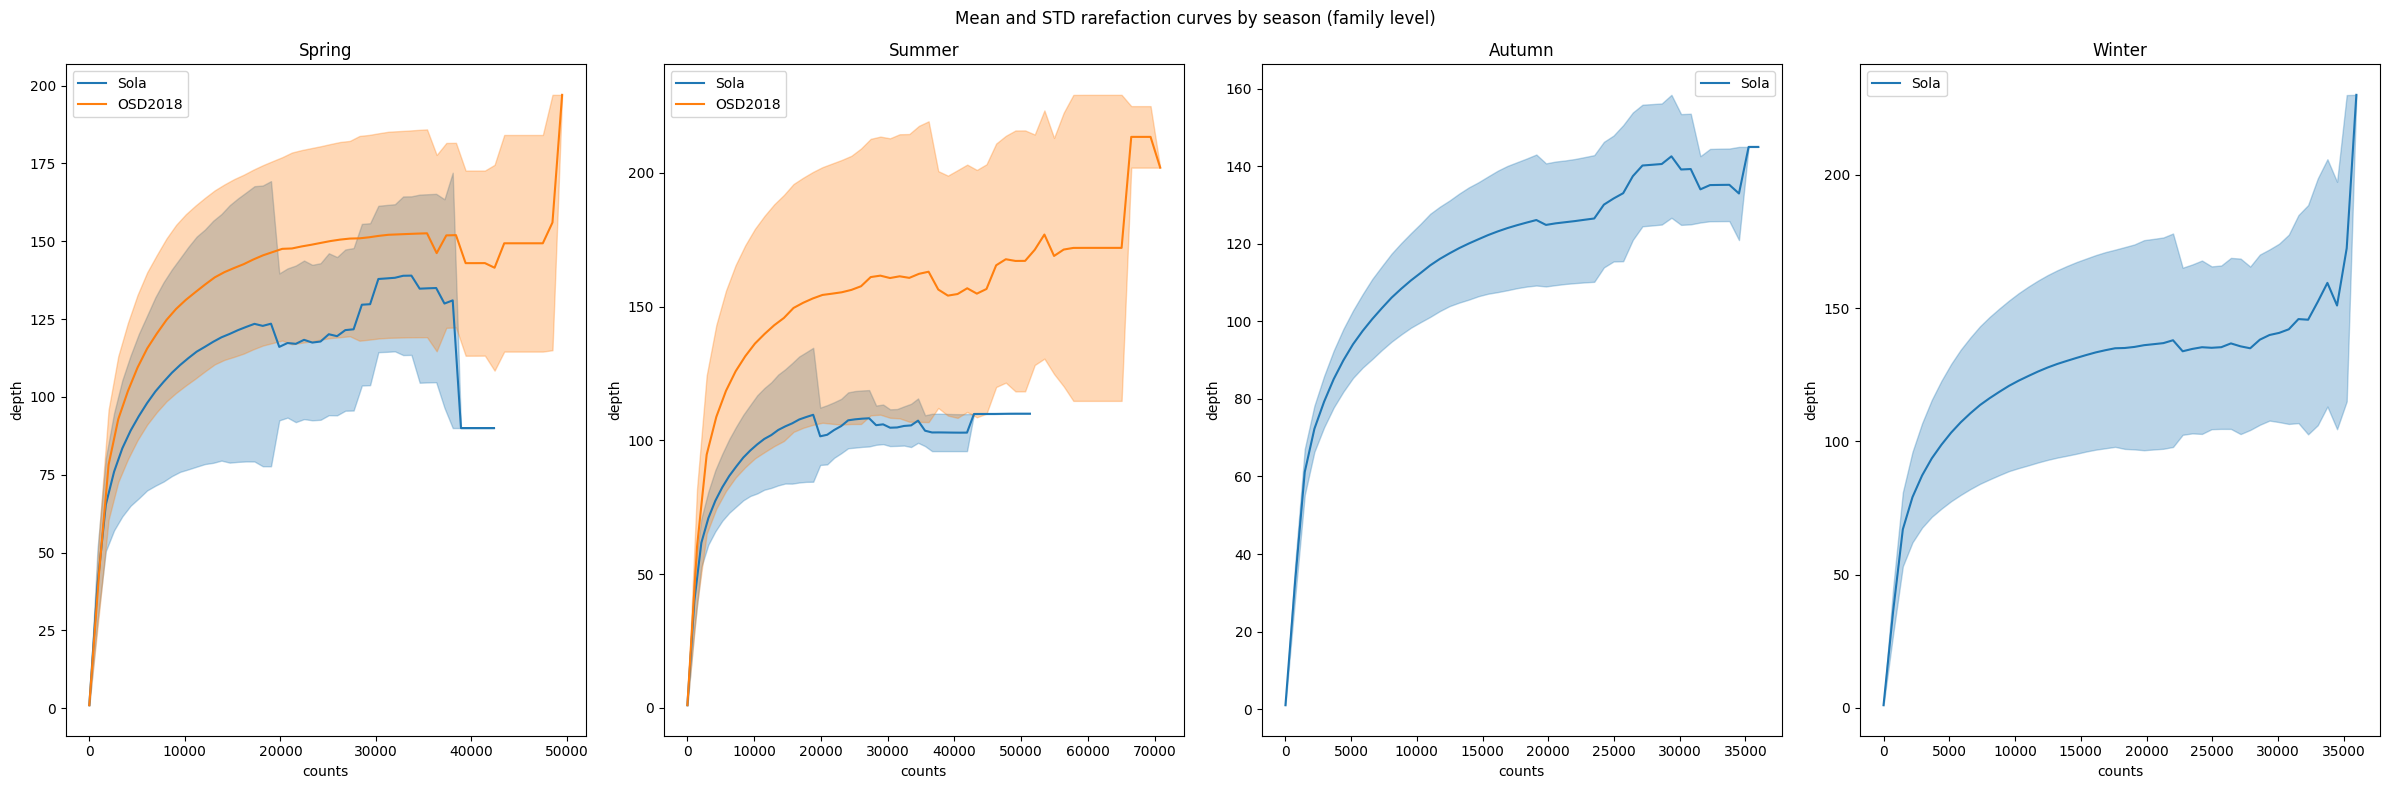

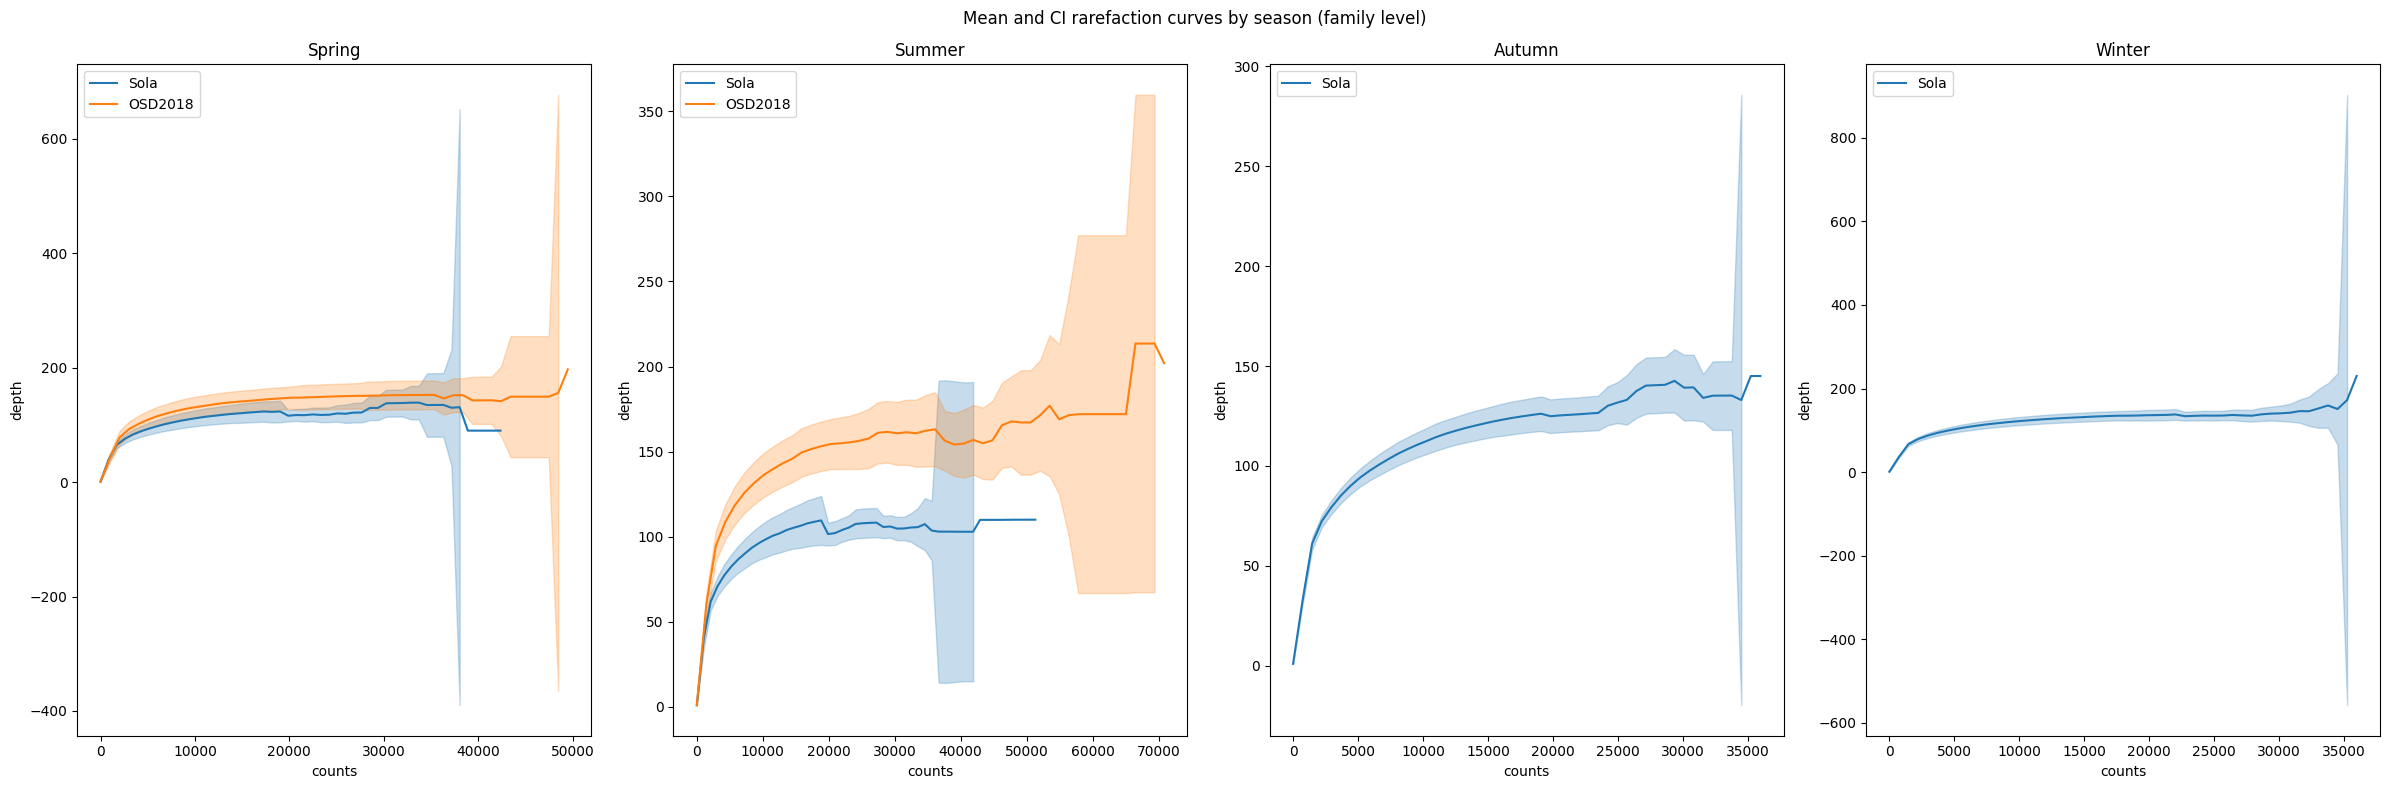

In [22]:
if CONFIG['rarefaction']['enabled'] and CONFIG['plots']['feature_rarefaction']:
    print(f"\n=== Rarefaction per {CONFIG['features']['primary_feature']} ===")
    
    feature = CONFIG['features']['primary_feature']
    features_dict = extract_feature_dict(analysis_meta, samples_meta, feature=feature)
    
    tax_level = CONFIG['taxonomy']['diversity_level']
    pkl_path = os.path.join(ANALYSIS_CACHE, f"rarefaction_curves_per_{feature}.pkl")
    
    # Check if already computed
    if os.path.exists(pkl_path):
        print("Loading cached feature rarefaction curves...")
        with open(pkl_path, 'rb') as f:
            curves_per_feature_val = pickle.load(f)
        calc_rarefaction = False
    else:
        print("Computing feature rarefaction curves...")
        calc_rarefaction = True
        curves_per_feature_val = {}
    
    # Prepare base data
    long_df_filt = aggregate_by_taxonomic_level(
        taxonomy_table.df, level=tax_level, dropna=dropna
    )
    df_filt_pivot = pivot_taxonomic_data(long_df_filt)
    df_filt_pivot = prevalence_cutoff_abund(
        df_filt_pivot, 
        percent=CONFIG['filtering']['prevalence_percent'], 
        skip_columns=0
    )
    
    # Process each feature value
    for feature_val, samples in features_dict.items():
        sample_subset = list(samples.keys())
        df_subset = df_filt_pivot[sample_subset]
        
        if calc_rarefaction:
            curves = defaultdict(list)
            curves = calc_rarefaction_curves(df_subset, analysis_meta, curves)
            curves_per_feature_val[feature_val] = curves
    
    if calc_rarefaction:
        with open(pkl_path, 'wb') as f:
            pickle.dump(curves_per_feature_val, f)
    
    # Plot mean + STD
    if CONFIG['plots']['rarefaction_mean_std']:
        feature_list = list(features_dict.keys())
        fig, axes = plt.subplots(1, len(feature_list), figsize=(6 * len(feature_list), 8))
        
        for ax, feature_val in zip(axes, feature_list):
            for campaign, curve_list in curves_per_feature_val[feature_val].items():
                x_common, mean_y, std_y, counts = mean_std_curves(
                    curve_list, n_points=CONFIG['rarefaction']['n_points']
                )
                plot_mean_std(x_common, mean_y, std_y, label=campaign, ax=ax, title=feature_val)
        
        plt.suptitle(f"Mean and STD rarefaction curves by {feature} ({tax_level} level)")
        plt.tight_layout()
        if CONFIG['plots']['save_figures']:
            plt.savefig(os.path.join(OUT_FOLDER, f'rarefaction_{feature}_mean_std.png'), 
                       dpi=CONFIG['plots']['dpi'])
        plt.show()
    
    # Plot mean + CI
    if CONFIG['plots']['rarefaction_mean_ci']:
        fig, axes = plt.subplots(1, len(feature_list), figsize=(6 * len(feature_list), 8))
        
        for ax, feature_val in zip(axes, feature_list):
            for campaign, curve_list in curves_per_feature_val[feature_val].items():
                x_common, mean_y, ci_lo, ci_hi, counts = mean_ci_curves(
                    curve_list, n_points=CONFIG['rarefaction']['n_points']
                )
                plot_mean_ci(x_common, mean_y, ci_lo, ci_hi, label=campaign, ax=ax, title=feature_val)
        
        plt.suptitle(f"Mean and CI rarefaction curves by {feature} ({tax_level} level)")
        plt.tight_layout()
        if CONFIG['plots']['save_figures']:
            plt.savefig(os.path.join(OUT_FOLDER, f'rarefaction_{feature}_mean_ci.png'), 
                       dpi=CONFIG['plots']['dpi'])
        plt.show()

## Summary

Analysis complete! Check the output folder for saved results and figures.

In [23]:
print("\n" + "="*60)
print("ANALYSIS SUMMARY")
print("="*60)
print(f"Output folder: {OUT_FOLDER}")
print(f"\nDatasets analyzed: {list(ds.keys())}")
print(f"Total samples: {len(analysis_meta)}")
print(f"Sample type: {sample_type}")
print(f"\nTaxonomic levels: {CONFIG['taxonomy']['analysis_levels']}")
print(f"Diversity level: {CONFIG['taxonomy']['diversity_level']}")
if CONFIG['rarefaction']['enabled']:
    print(f"\nRarefaction depth: {int(MIN_DEPTH)}")
print(f"\nFiltering:")
print(f"  Min reads: {CONFIG['filtering']['min_reads_cutoff']}")
print(f"  Prevalence cutoff: {CONFIG['filtering']['prevalence_percent']*100}%")
print(f"\nPrimary grouping feature: {CONFIG['features']['primary_feature']}")
print("="*60)


ANALYSIS SUMMARY
Output folder: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260206_1816

Datasets analyzed: ['Sola', 'OSD2018']
Total samples: 165
Sample type: prok

Taxonomic levels: ['phylum']
Diversity level: family

Rarefaction depth: 14591

Filtering:
  Min reads: 25000
  Prevalence cutoff: 0.5%

Primary grouping feature: season
